## Notebook 7: AC Electricity Consumption, Downscaling

In [1]:
# Repo-root discovery + import of cityheat
import sys
from pathlib import Path

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Could not find repo root with 'cityheat' and 'configs' folders.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
C = bootstrap("Rome")  # switch to "Barcelona" later

PROJECT, CITY, CFG, cfg = C["PROJECT"], C["CITY"], C["CFG"], C["cfg"]
OUT, INT, BASE = C["OUT"], C["INT"], C["BASE"]
p_LCZ, p_UrbClim, p_GVI, p_CoolEff = C["p_LCZ"], C["p_UrbClim"], C["p_GVI"], C["p_CoolEff"]

print("Repo root:", ROOT)
print("✔ Loaded config:", CFG)
print("→ Outputs:", OUT)
print("→ Data base:", BASE)

Repo root: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
✔ Loaded config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
→ Outputs: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome
→ Data base: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome


**Loading from before**

In [2]:
# path to the FUA geopackage saved in NB2
fua_path = OUT / "rome_fua.gpkg"
assert fua_path.exists(), f"Missing {fua_path} — re-run NB2 to save it."

In [3]:
# our Hazard for later 
import numpy as np

npz = np.load(INT / "wbgt_hot_days_2030_2100.npz")
YEARS = npz["years"]            # shape (n_years,)
DATA  = npz["data"]             # shape (n_years, HGT, WDT)
I2050 = DATA[YEARS.tolist().index(2050)]

In [9]:
import rasterio as rio
import geopandas as gpd 
import pandas as pd 

# from earlier notebooks
tmpl_path = INT / "template_ref.tif"   # reference WBGT grid (same as NB5)
mask_tif  = INT / "city_mask.tif"      # boolean mask on that grid
fua_gp    = OUT / "rome_fua.gpkg"      # saved in NB2 under layer="fua"

# loading ref grid + mask
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Coverage from notebook 6 
d = np.load(INT / "ac_coverage_maps.npz")
coverage_base   = d["coverage_base"].astype("float32")
coverage_policy = d["coverage_policy"].astype("float32")
CAP_MASK        = d["CAP_MASK"].astype(bool)

assert coverage_base.shape   == (HGT, WDT)
assert coverage_policy.shape == (HGT, WDT)

# files saved in NB2/NB3
age_npz = INT / "age_on_ref.npz"
pop_npz = INT / "pop_on_ref.npz"

# total pop per pixel
pop_on_ref = np.load(pop_npz)["pop"].astype(float)

# cap on ref
cap_on_ref = np.load(INT / "cap_on_ref.npz")["cap_on_ref"].astype("int32")

# polygons with cap_id/cap5 (same CRS as ref grid for any later plotting)
cap_ref = gpd.read_file(OUT / "rome_cap.gpkg", layer="cap").to_crs(ref_meta["crs"])

# or just the id↔cap5 lookup without geometry
cap_ref_lut = pd.read_csv(OUT / "cap_lut.csv")   # columns: cap_id, cap5

cap_4326 = gpd.read_file(OUT / "rome_cap.gpkg", layer="cap_wgs84")  # WGS84 polygons
cap_wgs84_lut = pd.read_csv(OUT / "cap_wgs84_lut.csv")              # id <-> cap5

In [10]:
# muni_on_ref (raster of Municipio IDs on WBGT ref grid)

import rasterio as rio
import numpy as np

tif_path = OUT / "muni_on_ref.tif"   # saved in NB5

with rio.open(tif_path) as src:
    muni_on_ref = src.read(1).astype("int32")
    # sanity: same grid as the WBGT reference
    assert src.crs == ref_meta["crs"], "CRS mismatch vs ref grid."
    assert src.transform == ref_meta["transform"], "Transform mismatch vs ref grid."
    assert muni_on_ref.shape == (ref_meta["height"], ref_meta["width"]), "Shape mismatch."

print("muni_on_ref loaded:", muni_on_ref.shape, "unique IDs:", np.unique(muni_on_ref).size)

muni_on_ref loaded: (266, 353) unique IDs: 17


In [11]:
# loading muni (vector) 
# Municipi vectors from the GPKG (notebook 5)
gpkg_path = OUT / "rome_regions.gpkg"
muni = gpd.read_file(gpkg_path, layer="muni")  # has columns: muni_id, muni_name, geometry
# keep a safe CRS
if muni.crs is None:
    muni = muni.set_crs("EPSG:4326")

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [12]:
gridded_AC = (BASE/"ac_kWh_ssp1_ssp2_ssp3_ssp5_2010_2050.nc")

In [13]:
import netCDF4 as nc
ds = nc.Dataset(gridded_AC)

In [14]:
print(ds)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Title: AC_electricity_consumption
    Source: Falchetta et al. (2023)
    References: Falchetta et al. (2023)
    Created on: Mon Aug 18 16:31:48 2025
    dimensions(sizes): longitude(720), latitude(360), SSP(4), Time(4)
    variables(dimensions): float64 longitude(longitude), float64 latitude(latitude), float64 SSP(SSP), float64 Time(Time), float32 ac_electricity_consumption(Time, SSP, latitude, longitude)
    groups: 


In [15]:
print(ds['ac_electricity_consumption'])

<class 'netCDF4.Variable'>
float32 ac_electricity_consumption(Time, SSP, latitude, longitude)
    units: kWh/hh/yr
    _FillValue: -999.0
    long_name: ac_average_household_electricity_consumption
unlimited dimensions: Time, SSP
current shape = (4, 4, 360, 720)
filling on


Missing values as -999

Before I was using a completely other technique where I was reprojecting the raster to our ref grid and aggregating over the city. But since it's one pixel for Rome I tried to intersect and find the Rome pixel. 

**Method 1: nearest non na pixel**

In [16]:
import xarray as xr, numpy as np, re

# opening the data 
ds = xr.open_dataset(gridded_AC, decode_times=False)

# helpers 
def pick_one(seq, options):
    for name in options:
        if name in seq: return name
    low = {s.lower(): s for s in seq}
    for name in options:
        if name.lower() in low: return low[name.lower()]
    return None
    
def select_label(vals, desired):
    """Picking ‘closest’ coord label"""
    vals_np = np.asarray(vals)
    # numeric labels
    if np.issubdtype(vals_np.dtype, np.number):
        idx = int(np.argmin(np.abs(vals_np - float(desired))))
        return vals_np[idx]
    # string labels (SSP2 / ssp2 / '2')
    want = str(desired)
    candidates = [want, f"SSP{int(desired)}", f"ssp{int(desired)}", f"{int(desired)}"]
    for c in candidates:
        m = [v for v in vals if str(v).lower() == c.lower()]
        if m: return m[0]
    m = [v for v in vals if str(int(desired)) in str(v)]
    return m[0] if m else vals[0]

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

def decode_years(tvals, units: str | None):
    tvals = np.asarray(tvals, dtype=float)
    if np.all((tvals >= 1800) & (tvals <= 2600)):
        return tvals.astype(int)
    units = (units or "").lower()
    m = re.search(r"years\s+since\s+(\d{4})", units)
    if m:
        base = int(m.group(1))
        return (base + tvals).astype(int)
    return tvals.astype(int)
    
# dims/var
DIM_LAT  = pick_one(ds.dims,  ["latitude","lat","y"])
DIM_LON  = pick_one(ds.dims,  ["longitude","lon","x"])
DIM_SSP  = pick_one(ds.dims,  ["SSP","ssp","scenario"])
DIM_TIME = pick_one(ds.dims,  ["Time","time","year"])

# variable => electricity to get AC electricity consumption 
def pick_var(ds):
    for v in ds.data_vars:
        hay = f"{v.lower()} " + " ".join(f"{k} {str(ds[v].attrs[k]).lower()}" for k in ds[v].attrs)
        if "ac" in hay and "electricity" in hay: return v
    return list(ds.data_vars)[0]

VAR = pick_var(ds)

# decoding and cleaning
years = decode_years(ds[DIM_TIME].values, ds[DIM_TIME].attrs.get("units",""))
ds = ds.assign_coords({DIM_TIME: years})

fill = ds[VAR].attrs.get("_FillValue", ds[VAR].encoding.get("_FillValue", None))
miss = ds[VAR].attrs.get("missing_value", None)
da = ds[VAR]
for mv in [fill, miss, -999.0]:
    if mv is not None:
        da = da.where(da != mv)

# we pick the scenario ssp 2 and the year 2050, as before for the AC penetration 
rome_lat, rome_lon = 41.9028, 12.4964
ssp_choice, year_choice = 2, 2050

ssp_label  = select_label(ds[DIM_SSP].values, ssp_choice)
time_vals  = np.asarray(ds[DIM_TIME].values)
year_label = time_vals[int(np.argmin(np.abs(time_vals - year_choice)))]

# 2D slice
sl = da.sel({DIM_SSP: ssp_label, DIM_TIME: year_label}).transpose(DIM_LAT, DIM_LON)

# nearest coord
lat0 = ds[DIM_LAT].sel({DIM_LAT: rome_lat}, method="nearest").item()
lon0 = ds[DIM_LON].sel({DIM_LON: rome_lon}, method="nearest").item()

# try nearest pixel
v_pix = float(sl.sel({DIM_LAT: lat0, DIM_LON: lon0}, method="nearest").values)
if np.isfinite(v_pix):
    method = "nearest_pixel"
    used_lat, used_lon = lat0, lon0
    dist_km = haversine_km(rome_lat, rome_lon, used_lat, used_lon)
    val = v_pix
else:
    # try bilinear interpolation
    v_int = float(sl.interp({DIM_LAT: rome_lat, DIM_LON: rome_lon}).values)
    if np.isfinite(v_int):
        method = "bilinear_interp"
        used_lat, used_lon = rome_lat, rome_lon
        dist_km = 0.0
        val = v_int
    else:
        # nearest non-NaN search
        LAT, LON = np.meshgrid(ds[DIM_LAT].values, ds[DIM_LON].values, indexing="ij")  # (lat,lon)
        mask = np.isfinite(sl.values)
        if mask.any():
            LATv, LONv, V = LAT[mask], LON[mask], sl.values[mask]
            d = haversine_km(rome_lat, rome_lon, LATv, LONv)
            idx = int(np.argmin(d))
            method = "nearest_non_nan"
            used_lat, used_lon = float(LATv[idx]), float(LONv[idx])
            dist_km = float(d[idx])
            val = float(V[idx])
        else:
            method = "all_nan"
            used_lat, used_lon, dist_km = np.nan, np.nan, np.nan
            val = np.nan

# diagnostics (3x3 window around nearest grid point)
ilat = int(np.argmin(np.abs(ds[DIM_LAT].values - lat0)))
ilon = int(np.argmin(np.abs(ds[DIM_LON].values - lon0)))
win = sl.isel({DIM_LAT: slice(max(0, ilat-1), ilat+2),
               DIM_LON: slice(max(0, ilon-1), ilon+2)})

# grid resolution
dlat = float(np.abs(np.diff(ds[DIM_LAT].values)).mean())
dlon = float(np.abs(np.diff(ds[DIM_LON].values)).mean())

print(f"SSP label used: {ssp_label} | Year label used: {int(year_label)}")
print(f"Nearest grid center to Rome: lat={lat0:.3f}, lon={lon0:.3f} (res≈{dlat:.3f}°×{dlon:.3f}°)")
print(f"Method: {method} | distance from Rome to used point: {dist_km:.2f} km")
print(f"AC electricity consumption (kWh/capita/yr)—SSP{int(ssp_choice)}, {int(year_choice)}: {val}")

# inspecting the 3x3 window to see if on a masked coastline/urban cell
print("3x3 window around nearest grid point:\n", np.array_str(win.values, precision=1, suppress_small=True))

SSP label used: 2.0 | Year label used: 2050
Nearest grid center to Rome: lat=41.750, lon=12.250 (res≈0.500°×0.500°)
Method: nearest_non_nan | distance from Rome to used point: 27.02 km
AC electricity consumption (kWh/capita/yr)—SSP2, 2050: 674.3500366210938
3x3 window around nearest grid point:
 [[1685.9 1739.3  886.8]
 [   nan    nan  674.4]
 [   nan    nan    nan]]


**Method 2**: gives same result: intersecting with FUA

In [17]:
import numpy as np, geopandas as gpd
from shapely.geometry import box
from shapely.ops import transform as shp_transform
from pyproj import Transformer, CRS

def edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    if centers.size < 2:
        step = 0.0
    else:
        d = np.diff(centers)
        step = float(np.mean(d))
    edge0 = centers[0] - 0.5 * step
    return edge0 + np.arange(centers.size + 1) * step

def ac_value_at_fua(sl2d, fua_gdf, max_ring=3, use_centroid=False):
    fua_ll = fua_gdf.to_crs("EPSG:4326").geometry.unary_union
    pt = fua_ll.centroid if use_centroid else fua_ll.representative_point()
    # if centroid accidentally lies outside 
    if not fua_ll.contains(pt):
        pt = fua_ll.representative_point()
    lat_pt, lon_pt = float(pt.y), float(pt.x)

    # dims and coordinates
    lat_name, lon_name = sl2d.dims
    lats = sl2d[lat_name].values
    lons = sl2d[lon_name].values
    lat_edges = edges_from_centers(lats)
    lon_edges = edges_from_centers(lons)

    # nearest indices
    ilat = int(np.argmin(np.abs(lats - lat_pt)))
    ilon = int(np.argmin(np.abs(lons - lon_pt)))

    # equal-area CRS (Europe) to measure overlap areas robustly
    to_ea = Transformer.from_crs("EPSG:4326", CRS.from_epsg(3035), always_xy=True).transform

    def cell_poly(i, j):
        # build lon/lat rectangle for cell i,j
        y0, y1 = float(lat_edges[i]), float(lat_edges[i+1])
        x0, x1 = float(lon_edges[j]), float(lon_edges[j+1])
        return box(min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1))

    # trying the containing (nearest) cell
    v0 = float(sl2d.values[ilat, ilon])
    if np.isfinite(v0):
        return {
            "value": v0,
            "method": "interior_point_cell",
            "cell_center": (float(lats[ilat]), float(lons[ilon])),
        }

    # expanding to neighbors, choosing overlapping non-na with largest intersection area
    best = None
    best_area = 0.0
    for ring in range(1, max_ring + 1):
        i0, i1 = max(0, ilat - ring), min(len(lats) - 2, ilat + ring)
        j0, j1 = max(0, ilon - ring), min(len(lons) - 2, ilon + ring)
        for i in range(i0, i1 + 1):
            for j in range(j0, j1 + 1):
                v = float(sl2d.values[i, j])
                if not np.isfinite(v):
                    continue
                poly = cell_poly(i, j)
                inter = poly.intersection(fua_ll)
                if inter.is_empty:
                    continue
                area = shp_transform(to_ea, inter).area  # m^2
                if area > best_area:
                    best_area = area
                    best = (i, j, v)
        if best is not None:
            i, j, v = best
            return {
                "value": v,
                "method": f"max_overlap_ring_{ring}",
                "cell_center": (float(lats[i]), float(lons[j])),
            }

    # nearest non-NaN (by Euclidean in index space)
    finite = np.isfinite(sl2d.values)
    if finite.any():
        ii, jj = np.where(finite)
        k = np.argmin((ii - ilat) ** 2 + (jj - ilon) ** 2)
        i, j = int(ii[k]), int(jj[k])
        v = float(sl2d.values[i, j])
        return {
            "value": v,
            "method": "nearest_non_nan",
            "cell_center": (float(lats[i]), float(lons[j])),
        }

    return {"value": np.nan, "method": "all_nan", "cell_center": (np.nan, np.nan)}

In [18]:
fua = gpd.read_file(fua_path).to_crs("EPSG:4326")
res = ac_value_at_fua(sl, fua, max_ring=3)
print(res["method"], res["cell_center"], res["value"])

max_overlap_ring_1 (41.75, 12.75) 674.3500366210938


/var/folders/jr/55yqw22n1_n4th6my741s7g00000gn/T/ipykernel_59568/2967377845.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fua_ll = fua_gdf.to_crs("EPSG:4326").geometry.unary_union


Actually these two methods give the same because they are basically the same => both fall back on nearest non nan pixel ... See if it's the right way to do it. I tried many other ways that were all giving the same results. 

**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [108]:
import pandas as pd

# Rome-wide per-AC-user average (kWh/user/yr) => evident: it's an electricity due to AC data : so conditional on having AC
per_user_city = 674.3500366210938 # per AC user 

ac_city   = 0.724                 # Roma AC share (households)
coverage_map = coverage_base            # pixel AC share (0..1)
pop_grid  = pop_on_ref              # people per pixel
cap_ids   = cap_on_ref              # CAP id per pixel (0 if none)

# QUESTION: MAYBE I SHOULDN'T HARDCODE THESE VALUES, I MEAN FOR LATER, FOR OTHER CITIES, 
# FOR SURE NOT: I WILL HAVE TO CREATE FUNCTION TO RETRIEVE THE VALUES WE JUST FOUND 
# (VERY EASY:NEXT STEP)

# building CAP-level hazard/heat index (pop-weighted) 
# we build a table of pixels to CAP
# for each CAP we compute the population-weighted mean of WBGT hot-days
# and the city pop-weighted mean heat
# This gives H_cap and H_city
CAP_PIX = CITY_MASK & np.isfinite(I2050) & (cap_ids > 0) # where CAP labels exist in the city
valid   = CAP_PIX & np.isfinite(pop_grid)  # safe pixels for aggregation

dfH = pd.DataFrame({
    "cap_id": cap_ids[valid].ravel().astype(int),
    "pop":    pop_grid[valid].ravel().astype(float),
    "H":      I2050[valid].ravel().astype(float),
})

def wavg(g): 
    w, x = g["pop"].to_numpy(), g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan
cap_H = dfH.groupby("cap_id").apply(wavg).reset_index(name="H_cap")
H_city = float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean())

# turning hotter CAP into wider spread into a sigma (standard deviation) per CAP 
# specifying how dispersion depends on hazard 
# Normal distribution: mean = per_user_city, std = sigma_cap
# tying sigma_cap to local heat via a simple power: sigma_cap = sigma0 * (H_cap/H_city)**gamma * per_user_city
rng    = np.random.default_rng(42)  
sigma0 = 0.20                       # baseline coefficient of variation (20% of mean)
gamma  = 1.0                        # elasticity of dispersion to hazard, double the heat: double the sigma
# if we want softer, put it < 1 

cap_draws = cap_H.copy()
ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0)
sigma_cap = sigma0 * (ratio ** gamma) * per_user_city

# drawing one per-user value per CAP from a Normal
# For each CAP, drawing a single per-AC-user consumption from Normal(mean = per_user_city, std = σ_cap)
# per_user_CAP_raw => one number per CAP, reflecting that G lives in hotter CAP than A SO likely uses more
mu = np.full_like(sigma_cap, per_user_city, dtype=float)
draws = rng.normal(loc=mu, scale=sigma_cap)
draws = np.clip(draws, 0.0, np.inf)   # truncate at 0 to avoid negatives
cap_draws["per_user_CAP_raw"] = draws.astype("float32")

# we could also make both mean and dispersion reflect the heat 

# back to CLIMADA grid 
lut = np.full(int(cap_ref["cap_id"].max())+1, np.nan, dtype="float32")
lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

# converting per-user to per-capita (overall) and totals
# multiplying by pixel AC share cov_map
kwh_pc_raw  = per_user_map * coverage_map                 # kWh per capita (overall) by pixel
# multiplying by pixel population to get kWh totals per pixel
kwh_tot_raw = kwh_pc_raw * pop_grid

# city target = “per-AC-user mean” × (# AC users citywide)
city_pop      = float(np.nansum(pop_grid[CITY_MASK]))

w = (coverage_map * pop_grid) * CITY_MASK
k = per_user_city / (np.nansum(per_user_map * w) / np.nansum(w))
per_user_map *= k

kwh_pc_map  = per_user_map * coverage_map
kwh_tot_map = kwh_pc_map  * pop_grid

cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
cap_per_user = cap_draws[["cap_id","per_user_CAP"]].rename(
    columns={"per_user_CAP": "kwh_per_user_cap"}
)

# users-weighted per-user mean (should be 674.3500…)
print("Per-user mean (city):", np.nansum(per_user_map * w) / np.nansum(w))

# AC share from map (should be 0.724 since we calibrated coverage)
ac_share_from_map = np.nansum(w) / np.nansum(pop_grid[CITY_MASK])
print("AC share from map:", ac_share_from_map)

# city total 
print("City total GWh:", np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)

# aggregating by CAP for reporting / CBA 
dfE = pd.DataFrame({
    "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
    "pop":    pop_grid[CITY_MASK].ravel().astype(float),
    "kwh":    kwh_tot_map[CITY_MASK].ravel().astype(float),
})
dfE = dfE[dfE["cap_id"] > 0]
cap_energy = (dfE.groupby("cap_id")
                .agg(pop_cap=("pop","sum"), kwh_cap=("kwh","sum"))
                .reset_index())
cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

Per-user mean (city): 674.3500337675454
AC share from map: 0.7240000033248384
City total GWh: 1245.1733000126767


**Map or CAP tables:**

City pop: 2,550,386
City AC users: 1,846,479  (AC share ≈ 0.724)
City total AC electricity: 1245.173 GWh/yr
City per-AC-user mean (users-weighted): 674.350034 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall)


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,62,0.849453,945.817139,44442.921702,3.570664e+07,803.426819
1,78,0.980000,773.501465,21326.933969,1.616649e+07,758.031433
2,107,0.980000,766.331482,9688.623348,7.276203e+06,751.004883
3,71,0.980000,743.416565,32566.940672,2.372659e+07,728.548218
4,110,0.980000,725.211243,28650.379437,2.036203e+07,710.707031
5,105,0.980000,715.094604,24873.100762,1.743089e+07,700.792725
6,112,0.980000,712.033081,24055.477581,1.678573e+07,697.792419
7,66,0.945279,737.515442,15728.025020,1.096492e+07,697.158203
8,61,0.964064,712.854309,36130.646179,2.483033e+07,687.237366
9,97,0.880928,778.805542,16598.421219,1.138771e+07,686.071777


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall)


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,92,0.513732,396.372131,27360.782808,5.571446e+06,203.628891
1,53,0.405796,563.046875,104346.731283,2.384135e+07,228.481995
2,103,0.451955,516.466125,11031.124709,2.574877e+06,233.419281
3,87,0.439559,565.338440,21520.388838,5.347807e+06,248.499573
4,88,0.423982,617.412903,35387.853865,9.263538e+06,261.771667
5,52,0.418803,629.077332,9058.825406,2.386633e+06,263.459412
6,86,0.446364,590.350098,34904.342830,9.197670e+06,263.510773
7,93,0.474489,610.509155,27361.907522,7.926197e+06,289.679993
8,48,0.432544,708.542664,37270.786251,1.142260e+07,306.475861
9,41,0.392157,783.848572,17485.160989,5.374791e+06,307.391541



Top 10 CAPs by kwh_cap — Total kWh


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,46,0.867230,712.007141,80953.751871,4.998681e+07,617.473633
1,83,0.493886,738.046326,124691.947115,4.545159e+07,364.511047
2,55,0.912417,642.314697,77100.784839,4.518562e+07,586.059143
3,63,0.980000,604.983398,72118.237776,4.275773e+07,592.883728
4,62,0.849453,945.817139,44442.921702,3.570664e+07,803.426819
5,59,0.695319,703.442749,66384.342286,3.246972e+07,489.117157
6,89,0.633414,871.970825,56399.959191,3.115073e+07,552.318298
7,50,0.803246,773.373779,49961.821113,3.103675e+07,621.209290
8,100,0.826737,787.077576,47341.841054,3.080564e+07,650.706360
9,73,0.587254,739.619812,70586.861995,3.065905e+07,434.345001


Bottom 10 CAPs by kwh_cap — Total kWh


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall
0,42,0.772858,759.830811,211.852069,1.244083e+05,587.241394
1,21,0.765966,559.185669,1286.516011,5.510369e+05,428.317169
2,24,0.768855,603.513550,2354.420032,1.092485e+06,464.014404
3,44,0.606898,664.018555,3906.593877,1.574323e+06,402.991333
4,19,0.762287,427.065582,5736.376812,1.867457e+06,325.546356
5,52,0.418803,629.077332,9058.825406,2.386633e+06,263.459412
6,103,0.451955,516.466125,11031.124709,2.574877e+06,233.419281
7,3,0.764453,561.143982,9041.909021,3.878689e+06,428.967957
8,33,0.767332,656.669312,8040.940718,4.051699e+06,503.883667
9,87,0.439559,565.338440,21520.388838,5.347807e+06,248.499573


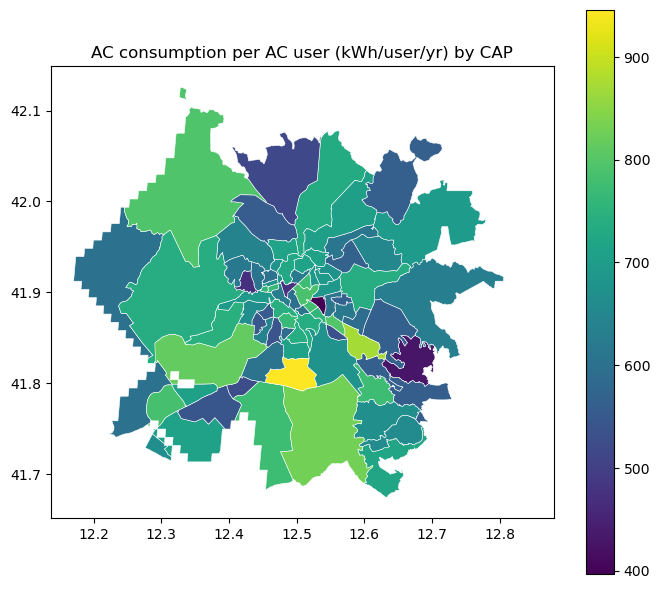

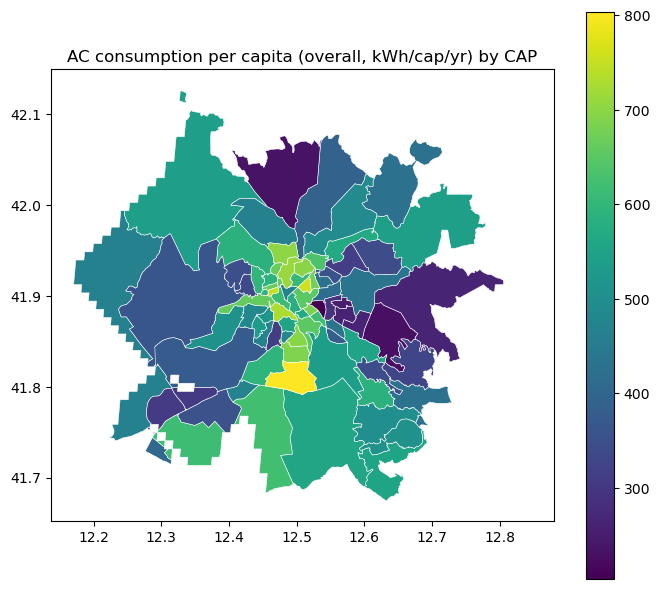

Saved: cap_ac_consumption_summary.csv, cap_ac_consumption_map.geojson


In [109]:
# CAP-level consumption tables & maps 

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# users and population by CAP (from pixel grid)
CAP_PIX = (cap_ids > 0) & CITY_MASK
df_cap_base = pd.DataFrame({
    "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
    "pop":    pop_grid[CAP_PIX].ravel().astype(float),
    "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
})

cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                 .agg(pop_cap=("pop","sum"),
                      users_cap=("users","sum")))
cap_pop_users["ac_share_cap"] = np.where(
    cap_pop_users["pop_cap"] > 0,
    cap_pop_users["users_cap"] / cap_pop_users["pop_cap"],
    np.nan
)

# energy totals by CAP (sum of pixel kWh)
df_kwh = pd.DataFrame({
    "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
    "kwh":    kwh_tot_map[CAP_PIX].ravel().astype(float),
})
cap_energy = (df_kwh.groupby("cap_id", as_index=False)
              .agg(kwh_cap=("kwh","sum")))

# merging into one CAP table and deriving per-capita overall
cap_tbl = (cap_pop_users
           .merge(cap_energy, on="cap_id", how="left")
           .merge(cap_per_user, on="cap_id", how="left"))

cap_tbl["kwh_pc_overall"] = np.where(
    cap_tbl["pop_cap"] > 0, cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan
)

# city checks 
city_pop     = float(np.nansum(pop_grid[CITY_MASK]))
city_users   = float(np.nansum((coverage_map * pop_grid)[CITY_MASK]))
city_kwh_GWh = float(np.nansum(kwh_tot_map[CITY_MASK]))/1e6
per_user_mean_city = float(np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"])) / max(city_users,1e-12)

print(f"City pop: {city_pop:,.0f}")
print(f"City AC users: {city_users:,.0f}  (AC share ≈ {city_users/city_pop:.3f})")
print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

# displaying top/bottom CAPs (per-capita overall and totals)
def show_rank(df, col, k=15, title=""):
    out = df[["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall"]].copy()
    out = out.sort_values(col, ascending=False).head(k)
    print(f"\nTop {k} CAPs by {col} — {title}")
    display(out.reset_index(drop=True))

    out_low = df[["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall"]].copy()
    out_low = out_low.sort_values(col, ascending=True).head(k)
    print(f"Bottom {k} CAPs by {col} — {title}")
    display(out_low.reset_index(drop=True))

show_rank(cap_tbl, "kwh_pc_overall", k=10, title="kWh per capita (overall)")
show_rank(cap_tbl, "kwh_cap",        k=10, title="Total kWh")

# joining to CAP polygons for maps
cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")

# maps 
fig, ax = plt.subplots(1, 1, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(
    ax=ax, column="kwh_per_user_cap", legend=True, linewidth=0.4, edgecolor="white"
)
ax.set_title("AC consumption per AC user (kWh/user/yr) by CAP")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7,6))
cap_map.to_crs("EPSG:4326").plot(
    ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white"
)
ax.set_title("AC consumption per capita (overall, kWh/cap/yr) by CAP")
plt.tight_layout()
plt.show()

# exporting in case we needed for CBA 
cap_tbl_out = cap_tbl.copy()
cap_tbl_out["kwh_GWh"] = cap_tbl_out["kwh_cap"]/1e6
cap_tbl_out.to_csv("cap_ac_consumption_summary.csv", index=False)

cap_map.to_crs("EPSG:4326")[["cap_id","geometry","kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]\
      .to_file("cap_ac_consumption_map.geojson", driver="GeoJSON")

print("Saved: cap_ac_consumption_summary.csv, cap_ac_consumption_map.geojson")

**So super nice because now the City total AC electricity: 1214.216 GWh/yr is just City AC users multiplied by City per-AC-user mean (our pixel value)!**

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**

In [110]:
# city_mask, pop_grid, cov_map, per_user_map, kwh_tot_map, muni_on_ref

def city_diag(mask, label):
    users = float(np.nansum((coverage_map * pop_grid)[mask]))
    per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
    kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
    pop = float(np.nansum(pop_grid[mask]))
    print(f"[{label}] per-user={per_user:.6f}  AC-share={users/pop:.3f}  total={kwh:.3f} GWh  pop={pop:,.0f}  users={users:,.0f}")
    return per_user, users, kwh

mask_all   = CITY_MASK
mask_in    = CITY_MASK & (muni_on_ref > 0)
mask_out   = CITY_MASK & (muni_on_ref == 0)

print("City diagnostics by universe:")
pu_all,  u_all,  k_all  = city_diag(mask_all, "ALL FUA ('city' prints)")
pu_in,   u_in,   k_in   = city_diag(mask_in,  "Municipi-only (muni_on_ref>0)")
pu_out,  u_out,  k_out  = city_diag(mask_out, "Outside Municipi (muni_id==0)")

print("\nCheck: in + out should equal all")
print("users:", u_in + u_out, "vs", u_all)
print("GWh:  ", k_in + k_out, "vs", k_all)

City diagnostics by universe:
[ALL FUA ('city' prints)] per-user=674.350032  AC-share=0.724  total=1245.173 GWh  pop=2,550,386  users=1,846,479
[Municipi-only (muni_on_ref>0)] per-user=673.469431  AC-share=0.722  total=1170.475 GWh  pop=2,407,470  users=1,737,977
[Outside Municipi (muni_id==0)] per-user=688.455475  AC-share=0.759  total=74.699 GWh  pop=142,915  users=108,502

Check: in + out should equal all
users: 1846479.1875848754 vs 1846479.1875848754
GWh:   1245.1733000126767 vs 1245.1733000126767



City diagnostics by universe:
[ALL FUA] per-user=674.350032  AC-share=0.724  total=1245.173 GWh  pop=2,550,386  users=1,846,479
[Municipi-only] per-user=673.469431  AC-share=0.722  total=1170.475 GWh  pop=2,407,470  users=1,737,977

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 674.3500337675451
City total GWh: 1245.1733000126767

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall)


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,2,0.953523,707.491236,161208.330674,1.087527e+08,674.609381
1,9,0.857591,728.709995,219039.173863,1.368853e+08,624.935063
2,1,0.949871,654.124071,179310.302304,1.114115e+08,621.333254
3,8,0.838050,701.565651,113726.641246,6.686528e+07,587.947385
4,15,0.844396,631.439739,98417.632343,5.247481e+07,533.185089
5,3,0.750078,687.101558,148266.813591,7.641376e+07,515.380056
6,7,0.701860,703.688436,248257.701068,1.226122e+08,493.890933
7,12,0.773514,635.996869,131970.543317,6.492327e+07,491.952769
8,14,0.730734,641.883535,158029.184353,7.412297e+07,469.046085
9,13,0.661222,678.172378,131022.060502,5.875321e+07,448.422280


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall)


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,6,0.419387,581.650888,130848.192714,3.191867e+07,243.936645
1,5,0.506244,630.050494,175631.613969,5.601931e+07,318.959127
2,4,0.581933,654.327495,170982.494694,6.510586e+07,380.775031
3,11,0.550277,710.879910,119537.334558,4.676076e+07,391.181203
4,10,0.673383,654.205031,221222.410330,9.745516e+07,440.530225
5,13,0.661222,678.172378,131022.060502,5.875321e+07,448.422280
6,14,0.730734,641.883535,158029.184353,7.412297e+07,469.046085
7,12,0.773514,635.996869,131970.543317,6.492327e+07,491.952769
8,7,0.701860,703.688436,248257.701068,1.226122e+08,493.890933
9,3,0.750078,687.101558,148266.813591,7.641376e+07,515.380056



Top 10 Municipi by kwh_muni — Total kWh


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,9,0.857591,728.709995,219039.173863,1.368853e+08,624.935063
1,7,0.701860,703.688436,248257.701068,1.226122e+08,493.890933
2,1,0.949871,654.124071,179310.302304,1.114115e+08,621.333254
3,2,0.953523,707.491236,161208.330674,1.087527e+08,674.609381
4,10,0.673383,654.205031,221222.410330,9.745516e+07,440.530225
5,3,0.750078,687.101558,148266.813591,7.641376e+07,515.380056
6,14,0.730734,641.883535,158029.184353,7.412297e+07,469.046085
7,8,0.838050,701.565651,113726.641246,6.686528e+07,587.947385
8,4,0.581933,654.327495,170982.494694,6.510586e+07,380.775031
9,12,0.773514,635.996869,131970.543317,6.492327e+07,491.952769


Bottom 10 Municipi by kwh_muni — Total kWh


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall
0,6,0.419387,581.650888,130848.192714,3.191867e+07,243.936645
1,11,0.550277,710.879910,119537.334558,4.676076e+07,391.181203
2,15,0.844396,631.439739,98417.632343,5.247481e+07,533.185089
3,5,0.506244,630.050494,175631.613969,5.601931e+07,318.959127
4,13,0.661222,678.172378,131022.060502,5.875321e+07,448.422280
5,12,0.773514,635.996869,131970.543317,6.492327e+07,491.952769
6,4,0.581933,654.327495,170982.494694,6.510586e+07,380.775031
7,8,0.838050,701.565651,113726.641246,6.686528e+07,587.947385
8,14,0.730734,641.883535,158029.184353,7.412297e+07,469.046085
9,3,0.750078,687.101558,148266.813591,7.641376e+07,515.380056


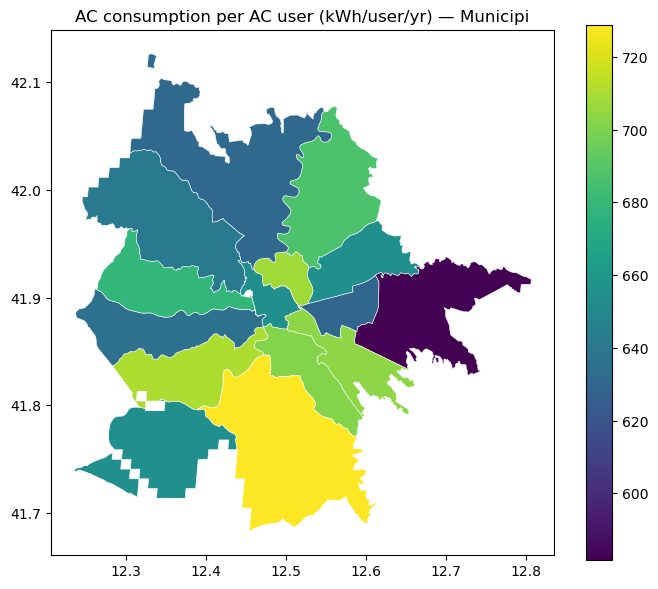

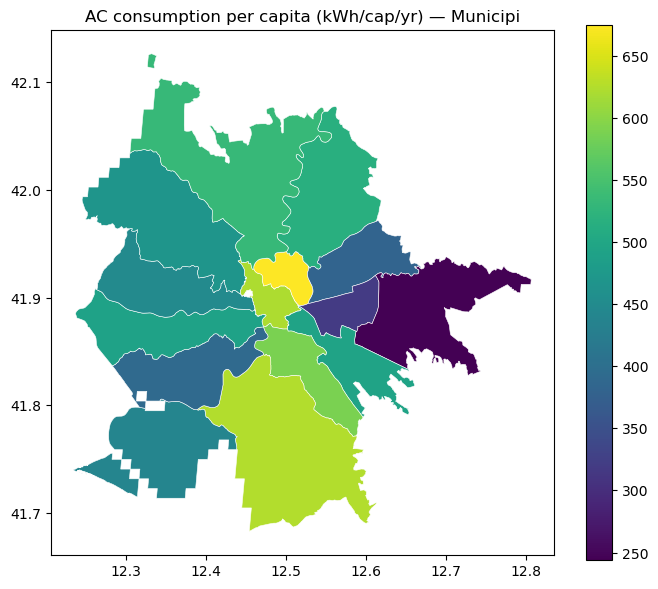

In [111]:
# Municipi AC electricity: per-user, per-capita, totals 
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt

pop_grid = pop_on_ref

# building pixel->Municipio table on the full city mask (include muni_id==0)
valid_all = CITY_MASK & np.isfinite(per_user_map) & np.isfinite(kwh_tot_map)
df = pd.DataFrame({
    "muni_id":  muni_on_ref[valid_all].ravel().astype(int),                 # includes 0 = outside Municipi
    "pop":      pop_grid[valid_all].ravel().astype(float),
    "users":   (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
    "kwh":      kwh_tot_map[valid_all].ravel().astype(float),
    "per_user": per_user_map[valid_all].ravel().astype(float),
})

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

per_user_by_muni = (df.groupby("muni_id")
                      .apply(lambda g: _wavg(g["per_user"], g["users"]))
                      .reset_index(name="kwh_per_user_muni"))

muni_tbl_all = (df.groupby("muni_id", as_index=False)
                  .agg(pop_muni=("pop","sum"),
                       users_muni=("users","sum"),
                       kwh_muni=("kwh","sum"))
                  .merge(per_user_by_muni, on="muni_id", how="left"))

muni_tbl_all["ac_share_muni"]  = np.where(muni_tbl_all["pop_muni"]>0,
                                          muni_tbl_all["users_muni"]/muni_tbl_all["pop_muni"], np.nan)
muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"]>0,
                                          muni_tbl_all["kwh_muni"]/muni_tbl_all["pop_muni"], np.nan)

# city diagnostics on both universes 
def city_diag(mask, label):
    users = float(np.nansum((coverage_map * pop_grid)[mask]))
    per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
    kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
    pop = float(np.nansum(pop_grid[mask]))
    print(f"[{label}] per-user={per_user:.6f}  AC-share={users/pop:.3f}  total={kwh:.3f} GWh  pop={pop:,.0f}  users={users:,.0f}")
    return per_user, users, kwh

mask_all = CITY_MASK
mask_in  = CITY_MASK & (muni_on_ref > 0)

print("\nCity diagnostics by universe:")
pu_all,  u_all,  k_all  = city_diag(mask_all, "ALL FUA")
pu_in,   u_in,   k_in   = city_diag(mask_in,  "Municipi-only")

# cross-check: Municipi + outside should equal ALL FUA
users_sum = float(muni_tbl_all["users_muni"].sum())
per_user_from_groups = float(np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"])
                             / max(users_sum, 1e-12))
kwh_sum = float(muni_tbl_all["kwh_muni"].sum())/1e6
print("\nFrom groupby (includes muni_id=0):")
print("Users-weighted per-user mean (city):", per_user_from_groups)
print("City total GWh:", kwh_sum)

# tables and maps for Municipi only (exclude id==0 for reporting)
muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()

def show_rank(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni","pop_muni","kwh_muni","kwh_pc_overall"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

show_rank(muni_only, "kwh_pc_overall", k=10, title="kWh per capita (overall)")
show_rank(muni_only, "kwh_muni",       k=10, title="Total kWh")

# maps (Municipi only)
muni_map = (muni[["muni_id","muni_name","geometry"]]
            .merge(muni_only, on="muni_id", how="left"))

fig, ax = plt.subplots(1,1, figsize=(7,6))
muni_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_per_user_muni",
                                  legend=True, linewidth=0.4, edgecolor="white")
ax.set_title("AC consumption per AC user (kWh/user/yr) — Municipi")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(7,6))
muni_map.to_crs("EPSG:4326").plot(ax=ax, column="kwh_pc_overall",
                                  legend=True, linewidth=0.4, edgecolor="white")
ax.set_title("AC consumption per capita (kWh/cap/yr) — Municipi")
plt.tight_layout(); plt.show()

In [112]:
# AC electricity (municipio energy table) 
from pathlib import Path
import pandas as pd

OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

assert 'muni_tbl_all' in globals(), "NB7: define `muni_tbl_all` before saving."
need = {'muni_id','pop_muni','users_muni','kwh_muni','kwh_per_user_muni','kwh_pc_overall'}
assert need.issubset(muni_tbl_all.columns), f"NB7: muni_tbl_all must include {need}."

cols = ['muni_id','pop_muni','users_muni','kwh_muni','kwh_per_user_muni','kwh_pc_overall']
extra = [c for c in ['ac_share_muni'] if c in muni_tbl_all.columns]
muni_tbl_all[cols+extra].to_csv(OUT / "muni_tbl_all.csv", index=False)
print("✓ Wrote", OUT / "muni_tbl_all.csv")

✓ Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/muni_tbl_all.csv
